# Penrose Diffraction Pattern from A₄ Coxeter Theory

## Prerequisites

This notebook is the diffraction-pattern companion to the Penrose tiling
notebook `penrose_ammann_coxeter.ipynb`. It is **self-contained for reading**
— the conceptual content does not require prior familiarity with the tiling
notebook — but shares Python infrastructure that must be available at runtime.

### Required files

- **`coxeter_a4.py`**: helper module providing four functions:
  - `build_a4_system()` — returns the A₄ root system, Weyl group, and
    Coxeter element matrix P
  - `build_eigenspaces(P)` — returns the cyclotomic field ℚ(ζ₅) and
    eigenvectors of P for the parallel and perpendicular 2-planes
  - `eigenvec_to_proj(w, K)` — converts a complex eigenvector to a 2×5
    real projection matrix
  - `algebraic_constants(K, zeta)` — returns exact ℚ(ζ₅) and numerical
    values of τ, σ, κ₁, and the Ammann-line constants m₁±, m₂±

- **Optional companion**: `penrose_ammann_coxeter.ipynb`, which derives
  the Penrose tiling itself from the same A₄ Coxeter structure. Reading
  it first provides additional context on the cut-and-project construction
  and the eigenspace decomposition, but is not strictly required.

### Required Python packages

- **SageMath 10.x** (for exact arithmetic in ℚ(ζ₅) and integer linear
  algebra)
- **NumPy** (for numerical projections and matrix operations)
- **Matplotlib** (for the three-panel diffraction plot)

### Intended audience

This notebook is written for readers with a general mathematics or physics
background encountering quasicrystal diffraction, Coxeter theory, or both
for the first time. Specialized prerequisites (representation theory of
Weyl groups, cyclotomic number fields, model-set theory) are not assumed;
each is introduced briefly in context. Readers seeking more depth are
pointed to specific external references in the text.

### What this notebook does

Starting from the A₄ root system, we derive:

1. The two 2-dimensional eigenspaces of the Coxeter element (the "parallel"
   physical space E∥ and the "perpendicular" phason space E⊥).
2. The weight lattice P(A₄) and its dual basis projections.
3. The sinc-product amplitude formula for the A₄ Penrose diffraction pattern.
4. A visual three-panel diffraction plot with coset-indexed color-coding.
5. Symbolic verification, in exact integer arithmetic, of the ten-fold
   dihedral symmetry (D₁₀) of the peak set.
6. Symbolic verification of the self-similarity under scaling by the
   golden ratio τ, realized as an exact integer-matrix identity M² = M + I.

The unifying claim: the quasicrystalline features of the Penrose diffraction
pattern — 10-fold rotational symmetry, golden-ratio self-similarity, a
dense-but-countable set of sharp peaks — are all exact consequences of
integer-matrix identities derived from the A₄ Coxeter element, not
approximations or statistical averages.

### References
- D. Levine and P. Steinhardt, *Quasicrystals. I. Definition and structure*
Phys. Rev. B 34 (1986), 596-616.
- L. Boyle and P. Steinhardt, *Coxeter Pairs, Ammann Patterns, and
  Penrose-like Tilings*, arXiv:1608.08215.
- A. Hof, *On diffraction by aperiodic structures*, Commun. Math. Phys.
  169 (1995), 25–43.
- M. Schlottmann, *Generalized model sets and dynamical systems*, in
  *Directions in Mathematical Quasicrystals*, AMS (2000).
- M. Baake and U. Grimm, *Aperiodic Order, Vol. 1: A Mathematical
  Invitation*, Cambridge University Press (2013).


In [1]:
import sys
sys.path.insert(0, '..')
from coxeter_a4 import build_a4_system, build_eigenspaces, eigenvec_to_proj, algebraic_constants

from sage.all import n as numerical
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection


## 1. A₄ root system and Coxeter element

The Coxeter element of W(A₄) = S₅ is the product of all simple reflections
taken in order: cox = s₁·s₂·s₃·s₄. Its matrix representation in the ε-basis
is the 5×5 cyclic permutation P: εᵢ → εᵢ₊₁ (mod 5). This is the same matrix
used in the Penrose cut-and-project construction.


In [2]:
R, ambient, W, s, cox, P = build_a4_system()
print('Coxeter element matrix P (cyclic permutation εᵢ → εᵢ₊₁):')
print(P)


Coxeter element matrix P (cyclic permutation εᵢ → εᵢ₊₁):
[0 0 0 0 1]
[1 0 0 0 0]
[0 1 0 0 0]
[0 0 1 0 0]
[0 0 0 1 0]


## 2. Eigenspaces over ℚ(ζ₅): parallel and perpendicular planes

P has eigenvalues ωᵏ = e^(2πik/5) for k = 0,1,2,3,4. The two real 2-planes of
interest are:

- **E∥** (k = 1,4, eigenvalue ζ₅ and ζ₅⁴): rotation by 72° — physical space
  of the Penrose tiling
- **E⊥** (k = 2,3, eigenvalue ζ₅² and ζ₅³): rotation by 144° — phason space


In [3]:
K, zeta, w_par, w_perp = build_eigenspaces(P)
print('E∥ eigenvector (over ℚ(ζ₅)):', w_par)
print('E⊥ eigenvector (over ℚ(ζ₅)):', w_perp)


E∥ eigenvector (over ℚ(ζ₅)): (1, -zeta5^3 - zeta5^2 - zeta5 - 1, zeta5^3, zeta5^2, zeta5)
E⊥ eigenvector (over ℚ(ζ₅)): (1, zeta5^3, zeta5, -zeta5^3 - zeta5^2 - zeta5 - 1, zeta5^2)


## 3. Projection matrices for E∥ and E⊥

Each complex eigenvector w splits into real and imaginary parts via the complex
embedding K → ℂ. These two real 5-vectors span the corresponding eigenplane and,
after normalization, form a 2×5 orthonormal projection matrix.


In [4]:
proj_par  = eigenvec_to_proj(w_par,  K)   # 2x5, E∥
proj_perp = eigenvec_to_proj(w_perp, K)   # 2x5, E⊥

print('E∥ projection matrix (2x5):')
print(proj_par)
print('E⊥ projection matrix (2x5):')
print(proj_perp)

# Verify rotation angles between consecutive projected basis vectors
eps = np.eye(5)
e1_par  = proj_par  @ eps[1]; e1_par  /= np.linalg.norm(e1_par)
e2_par  = proj_par  @ eps[2]; e2_par  /= np.linalg.norm(e2_par)
e1_perp = proj_perp @ eps[1]; e1_perp /= np.linalg.norm(e1_perp)
e2_perp = proj_perp @ eps[2]; e2_perp /= np.linalg.norm(e2_perp)
angle_par  = np.degrees(np.arccos(np.clip(np.dot(e1_par,  e2_par),  -1, 1)))
angle_perp = np.degrees(np.arccos(np.clip(np.dot(e1_perp, e2_perp), -1, 1)))
print(f'Angle between consecutive E∥  basis vectors: {angle_par:.4f} deg (expect 72 deg)')
print(f'Angle between consecutive E⊥ basis vectors: {angle_perp:.4f} deg (expect 144 deg)')


E∥ projection matrix (2x5):
[[ 0.63245553  0.19543951 -0.51166727 -0.51166727  0.19543951]
 [-0.          0.60150096  0.37174803 -0.37174803 -0.60150096]]
E⊥ projection matrix (2x5):
[[ 0.63245553 -0.51166727  0.19543951  0.19543951 -0.51166727]
 [-0.          0.37174803 -0.60150096  0.60150096 -0.37174803]]
Angle between consecutive E∥  basis vectors: 72.0000 deg (expect 72 deg)
Angle between consecutive E⊥ basis vectors: 144.0000 deg (expect 144 deg)


## 4. Weight lattice P(A₄)

The **weight lattice** P(A₄) is the dual of the root lattice Q(A₄) inside the
A₄ hyperplane H = {x ∈ ℝ⁵ : Σxᵢ = 0}. It is generated by the four
**fundamental weights** ω₁, …, ω₄, defined by the duality

$$\langle \omega_i, \alpha_j \rangle = \delta_{ij}$$

with the simple roots αⱼ = εⱼ − εⱼ₊₁. Two natural lifts to the ambient
space ℝ⁵ = V give the same element of the quotient V/E₀:

- **Sage's default lift** (returned by `ambient.fundamental_weights()`):
  ωₖ = ε₁ + ε₂ + ⋯ + εₖ (integer entries, lies outside H)
- **Hyperplane lift** (used throughout this notebook):
  ωₖ = Σᵢ≤ₖ εᵢ − (k/5) Σᵢ εᵢ (entries in (1/5)ℤ, lies in H)

The two lifts differ by an element of E₀ = ℝ(1,1,1,1,1), which is
annihilated by both π∥ and π⊥. The hyperplane lift is preferred here
because the sinc-product amplitude formula of §7 reads the raw ε-basis
coordinates as 5-vector entries, and it is the (1/5)ℤ structure of the
hyperplane lift that encodes the four-layer structure of the Penrose
model set.

**Remark.** The first fundamental weight ω₁ = (4/5, −1/5, −1/5, −1/5, −1/5)
is — up to sign — is one choice for the canonical shift vector q₀ used in the
companion tiling notebook. This is not arbitrary: ω₁ is a **minuscule
weight** of A₄, meaning its Weyl orbit consists of vectors differing
pairwise by roots. This orbit has five elements, corresponding to the
five slices of the 5-hypercube by Σxᵢ = c (c = 0,…,5, with c=0 and c=5
degenerate). The Penrose tiling is the cut-and-project construction
associated to this minuscule representation of A₄.


In [5]:
# Extract the four fundamental weights of A_4 from the Sage ambient object.
# Sage returns the lift omega_k = eps_1 + ... + eps_k, which satisfies
# <omega_k, alpha_j> = delta_{kj} but has a nonzero component along
# E_0 = R(1,1,1,1,1). We explicitly project into the A_4 hyperplane
# H = {sum x_i = 0} to get the canonical form
#     omega_k = sum_{i<=k} eps_i - (k/5) sum_i eps_i
# whose entries lie in (1/5)Z. This is the form required by the sinc-product
# amplitude formula of §7. The projection onto E_par and E_perp is unaffected
# by the choice of lift (both kill E_0), so this change is invisible at
# the level of peak positions and amplitudes.

from sage.all import Matrix, QQ, vector, identity_matrix

alpha = ambient.simple_roots()
omega_sage = ambient.fundamental_weights()
ones5 = vector(QQ, [1, 1, 1, 1, 1])

# Project each Sage fundamental weight into the A_4 hyperplane
omega = {}
for k in range(1, 5):
    w = omega_sage[k].to_vector()
    omega[k] = w - (sum(w) / 5) * ones5    # sum(w) = k, so subtracts (k/5)*ones

print('A_4 fundamental weights (hyperplane lift, in eps-basis):')
for k in range(1, 5):
    print(f'  omega_{k} = {omega[k]}')

# Verify duality <omega_i, alpha_j> = delta_{ij} still holds
print('\nDuality check <omega_i, alpha_j> = delta_{ij}:')
duality_matrix = Matrix(QQ, 4, 4,
    lambda i, j: omega[i+1].inner_product(alpha[j+1].to_vector()))
print(duality_matrix)
assert duality_matrix == Matrix.identity(QQ, 4), 'Duality check failed'
print('OK: omega_i . alpha_j = delta_{ij} (exact)')

# Verify hyperplane condition: each omega_k now satisfies sum (omega_k)_i = 0
print('\nHyperplane check (sum (omega_k)_i should be 0):')
for k in range(1, 5):
    s = sum(omega[k])
    print(f'  sum(omega_{k}) = {s}')
    assert s == 0, f'omega_{k} not in hyperplane'
print('OK: All omega_k lie in H = {sum x_i = 0}')

# Verify the 1/5 structure: every omega_k entry now lies in (1/5)Z
print('\nFractional structure check (all entries should be in (1/5)Z):')
for k in range(1, 5):
    denominators = [QQ(e).denominator() for e in omega[k]]
    print(f'  omega_{k} entry denominators: {denominators}')
    assert all(d in (1, 5) for d in denominators), f'omega_{k} has non-(1/5)Z entry'
print('OK: All omega_k entries lie in (1/5)Z')

# Minuscule-weight remark: omega_1 equals the canonical q_0 (up to sign)
print(f'\nomega_1 = {omega[1]}  (compare to q_0 = (4/5, -1/5, -1/5, -1/5, -1/5))')


A_4 fundamental weights (hyperplane lift, in eps-basis):
  omega_1 = (4/5, -1/5, -1/5, -1/5, -1/5)
  omega_2 = (3/5, 3/5, -2/5, -2/5, -2/5)
  omega_3 = (2/5, 2/5, 2/5, -3/5, -3/5)
  omega_4 = (1/5, 1/5, 1/5, 1/5, -4/5)

Duality check <omega_i, alpha_j> = delta_{ij}:
[1 0 0 0]
[0 1 0 0]
[0 0 1 0]
[0 0 0 1]
OK: omega_i . alpha_j = delta_{ij} (exact)

Hyperplane check (sum (omega_k)_i should be 0):
  sum(omega_1) = 0
  sum(omega_2) = 0
  sum(omega_3) = 0
  sum(omega_4) = 0
OK: All omega_k lie in H = {sum x_i = 0}

Fractional structure check (all entries should be in (1/5)Z):
  omega_1 entry denominators: [5, 5, 5, 5, 5]
  omega_2 entry denominators: [5, 5, 5, 5, 5]
  omega_3 entry denominators: [5, 5, 5, 5, 5]
  omega_4 entry denominators: [5, 5, 5, 5, 5]
OK: All omega_k entries lie in (1/5)Z

omega_1 = (4/5, -1/5, -1/5, -1/5, -1/5)  (compare to q_0 = (4/5, -1/5, -1/5, -1/5, -1/5))


## 5. Dual basis in E∥ and E⊥

The projections of the fundamental weights onto the two 2-planes give the
dual basis for reciprocal space:

$$\omega_k^+ = \pi_\parallel(\omega_k) \in E_\parallel \quad \text{(peak position basis)}$$
$$\omega_k^- = \pi_\perp(\omega_k) \in E_\perp \quad \text{(peak amplitude basis)}$$

Every Bragg peak of the Penrose model set has position

$$k^+(\mathbf{n}) = \sum_k n_k \omega_k^+ \quad \text{for some } \mathbf{n} = (n_1, n_2, n_3, n_4) \in \mathbb{Z}^4$$

and its amplitude is controlled by the Galois-conjugate 5-vector
ξ(n) = π⊥(Σₖ nₖ ωₖ) (still a vector in the full ε-basis) via the
sinc-product formula of §7.


In [6]:
# Project each fundamental weight to E_par and E_perp
omega_vec = np.array([[float(c) for c in omega[k]]
                      for k in range(1, 5)])    # shape (4, 5)

omega_plus  = omega_vec @ proj_par.T    # shape (4, 2), parallel projections
omega_minus = omega_vec @ proj_perp.T   # shape (4, 2), perpendicular projections

print('Dual basis in E∥  (peak position basis):')
for k in range(4):
    print(f'  omega_{k+1}_plus = {omega_plus[k]}   |.| = {np.linalg.norm(omega_plus[k]):.6f}')

print('\nDual basis in E⊥ (controls peak amplitudes):')
for k in range(4):
    print(f'  omega_{k+1}_minus = {omega_minus[k]}   |.| = {np.linalg.norm(omega_minus[k]):.6f}')

# Compare magnitudes: Galois-conjugate-related ratios
print(f'\nMagnitude ratios |omega_k_minus|/|omega_k_plus|:')
for k in range(4):
    r = np.linalg.norm(omega_minus[k]) / np.linalg.norm(omega_plus[k])
    print(f'  k={k+1}: {r:.6f}')

# Numerical rotation sanity check: P should send omega_1 to omega_2 - omega_1.
# Verify that pi_par(omega_2 - omega_1) equals pi_par(omega_1) rotated by 72 deg.
theta = 2*np.pi/5
R72 = np.array([[np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]])
lhs = R72 @ omega_plus[0]
rhs = omega_plus[1] - omega_plus[0]
print(f'\nCoxeter rotation sanity check (numerical):')
print(f'  R(72 deg) * omega_1_plus = {lhs}')
print(f'  omega_2_plus - omega_1_plus = {rhs}')
print(f'  match (within 1e-10)? {np.allclose(lhs, rhs, atol=1e-10)}')


Dual basis in E∥  (peak position basis):
  omega_1_plus = [ 6.32455532e-01 -7.19978571e-18]   |.| = 0.632456
  omega_2_plus = [0.82789504 0.60150096]   |.| = 1.023335
  omega_3_plus = [0.31622777 0.97324899]   |.| = 1.023335
  omega_4_plus = [-0.19543951  0.60150096]   |.| = 0.632456

Dual basis in E⊥ (controls peak amplitudes):
  omega_1_minus = [ 6.32455532e-01 -2.08527858e-17]   |.| = 0.632456
  omega_2_minus = [0.12078826 0.37174803]   |.| = 0.390879
  omega_3_minus = [ 0.31622777 -0.22975292]   |.| = 0.390879
  omega_4_minus = [0.51166727 0.37174803]   |.| = 0.632456

Magnitude ratios |omega_k_minus|/|omega_k_plus|:
  k=1: 1.000000
  k=2: 0.381966
  k=3: 0.381966
  k=4: 1.000000

Coxeter rotation sanity check (numerical):
  R(72 deg) * omega_1_plus = [0.19543951 0.60150096]
  omega_2_plus - omega_1_plus = [0.19543951 0.60150096]
  match (within 1e-10)? True


## 6. Equivalence to the ℤ⁵/(1,1,1,1,1) convention

A common alternative parameterization of the reciprocal lattice uses ℤ⁵
directly, with the dual-lattice points labeled by 5-tuples
n = (n₀, n₁, n₂, n₃, n₄) ∈ ℤ⁵, and ambient vectors pulled back as

$$\ell^*(\mathbf{n}) = \sum_{j=0}^{4} n_j \varepsilon_j \in V = \mathbb{R}^5$$

In this convention, the all-ones vector (1,1,1,1,1) ∈ ℤ⁵ spans E₀ and is
annihilated by both projections, so two 5-tuples differing by a multiple
of (1,1,1,1,1) give the same peak. The effective dual lattice is
ℤ⁵/ℤ(1,1,1,1,1), which has rank 4.

**The two conventions are equivalent.** The weight lattice P(A₄) (our
choice) is a finite-index sublattice of ℤ⁵/ℤ(1,1,1,1,1), related by a
specific ℤ-linear change of basis. After projection to E∥ or E⊥ — both of
which annihilate E₀ — the two lattices map to the same rank-4 ℤ-module in
each 2-plane.

We use P(A₄) here because it is the mathematically canonical object
(the dual of the A₄ root lattice) and because it has rank 4 natively,
avoiding the need to quotient out the (1,1,1,1,1) direction. A reader
preferring the ℤ⁵ formulation may substitute
Σⱼ nⱼ π∥(εⱼ) = √(2/5) Σⱼ nⱼ aⱼ⁺ in place of the ωₖ⁺ basis used below,
with identical resulting peak positions.


## 7. Diffraction of a non-periodic structure

### What a diffraction pattern is

When a wave (X-rays, electrons, neutrons) scatters from a material, the
scattered intensity as a function of scattering direction forms the
**diffraction pattern**. For a point set Λ — atoms, or vertices, or any
discrete set of scatterers — the diffraction pattern is proportional to
the magnitude-squared Fourier transform of the density

$$\rho(\mathbf{r}) = \sum_{v \in \Lambda} \delta(\mathbf{r} - v)$$

evaluated at a reciprocal-space vector k:

$$I(\mathbf{k}) \propto |F(\mathbf{k})|^2, \quad F(\mathbf{k}) = \sum_{v \in \Lambda} e^{-2\pi i \mathbf{k} \cdot v}$$

For a crystal — a point set invariant under a lattice of translations — F(k)
is nonzero only on a discrete reciprocal lattice, giving the familiar sharp
spots of crystallography. This sharp-peak structure is usually presented as
a direct consequence of translational symmetry: the Fourier transform of a
translationally-invariant structure is supported on the dual lattice.

### What diffraction means for a non-periodic structure

A Penrose tiling has **no nonzero translational symmetries**. No vector
v ≠ 0 satisfies "the tiling shifted by v equals the tiling." This is the
defining feature of aperiodic order.

A naive reading of the crystal story would conclude: "no translations means
no sharp peaks." But this conclusion is wrong — Penrose tilings produce
**sharp Bragg peaks**, experimentally and mathematically. This apparent
paradox is what made Shechtman's 1982 discovery of icosahedral quasicrystals
(which show a 5-fold-symmetric diffraction pattern, forbidden for any
periodic crystal) so controversial at the time.

The resolution is that sharp peaks reflect not translational symmetry per
se, but a weaker quantity: **the autocorrelation structure** of the point
set. The autocorrelation

$$\gamma(\mathbf{v}) = \text{density of pairs } \{(x, y) \in \Lambda \times \Lambda : x - y = \mathbf{v}\}$$

records how often each difference vector v appears among pairs of points in
Λ. For a crystal, γ is itself a lattice measure, and its Fourier transform
gives the Bragg peaks. For a Penrose tiling, γ is not a lattice measure —
but it is still *pure point* (supported on a countable set of v-values).
Its Fourier transform therefore still consists of sharp peaks. The peaks
happen to form a dense rather than discrete set in reciprocal space, but
they are sharp peaks nonetheless.

### What symmetries a diffraction pattern can encode

This distinction matters for interpreting the symmetries we will observe in
the pattern. The A₄ Penrose diffraction pattern exhibits:

- **Ten-fold rotational symmetry** (5-fold rotation combined with inversion)
- **Self-similarity under scaling by the golden ratio τ ≈ 1.618**
- **Countably many sharp peaks densely filling reciprocal space**

None of these imply that the Penrose tiling has the corresponding symmetries
as spatial transformations. A Penrose tiling is not invariant under rotation
by 72° (pick any tiling; rotate it; you get a *different* tiling). It is not
invariant under scaling by τ (scaling produces a tiling with τ-times-larger
tiles). It is not periodic.

What these symmetries *do* tell us: they are symmetries of the **local
isomorphism class** of the tiling — the set of all tilings that are locally
indistinguishable from the given one. Two tilings are locally indistinguishable
if every finite patch appearing in one also appears in the other, with the
same asymptotic frequency. The Penrose LI class is invariant under 72°
rotation (rotated tilings are LI-equivalent to the original) and under
τ-inflation (the Robinson/Penrose inflation rule produces a tiling locally
indistinguishable from the starting one, just τ-times bigger). The
autocorrelation γ, and hence the diffraction pattern, is the same for every
tiling in the LI class, so it inherits every LI-class symmetry.

The diffraction pattern is therefore a **signature of the LI class**, not of
any individual tiling. Its symmetries are the hidden higher-dimensional
symmetries of the cut-and-project construction, made visible in 2D by the
Fourier transform.

### The amplitude formula for A₄ Penrose

For the specific case of the A₄ Penrose cut-and-project construction, the
diffraction measure can be written in closed form. The infinite vertex set
Λ ⊂ E∥ is a **Meyer model set**: a projection of the integer lattice ℤ⁵
restricted to a strip with an acceptance window Ω ⊂ E⊥. The Hof/Schlottmann
diffraction theorem, specialized to this setting, states:

**Theorem.** The diffraction measure of Λ is pure point, supported on
π∥(P(A₄)), where P(A₄) is the A₄ weight lattice (§4). The amplitude at the
peak k⁺ = π∥(ℓ*) is

$$A(\ell^*) = \prod_{j=0}^{4} \text{sinc}(\pi \cdot \ell_j^*)$$

where ℓ₀*, …, ℓ₄* are the ε-basis coordinates of ℓ* (a 5-vector with entries
in (1/5)ℤ, summing to zero), and sinc(x) = sin(x)/x with sinc(0) = 1.

**Three properties of the formula worth noting:**

1. **Reality.** Since Σⱼ ℓⱼ* = 0 (weight lattice points lie in the A₄
   hyperplane), the overall phase in the product vanishes and A(ℓ*) is a
   real number. Its sign can be either positive or negative, but
   intensities I = |A|² are always non-negative.

2. **Layer structure built in.** The (1/5)ℤ arithmetic of weight lattice
   points means the sinc arguments are always fifths of π, and the product
   automatically encodes the four-layer structure of the Penrose window
   (the slices of the 5-hypercube by Σxᵢ = 1, 2, 3, 4). No separate layer
   summation is required.

3. **Symmetry.** The product is invariant under any permutation of the
   indices j, because multiplication is commutative. The Weyl group
   W(A₄) = S₅ acts on V by permuting ε-coordinates, so it automatically
   preserves A(ℓ*). The Coxeter element — a specific 5-cycle in S₅ — is
   the geometric rotation by 72° on E∥, and its invariance of the amplitude
   formula is the algebraic source of the observed ten-fold symmetry.

**Normalization.** We use A(0) = 1 throughout — the forward-scattered peak
has unit amplitude by convention, and all other intensities are dimensionless
ratios relative to it. The shift vector q₀ contributes only an overall phase
exp(−2πi ℓ*·q₀) that drops out of |A|² and is omitted.

### References

The diffraction theory for Meyer model sets was developed by Hof and
Schlottmann in the 1990s:

- A. Hof, *On diffraction by aperiodic structures*, Commun. Math. Phys.
  169 (1995), 25–43.
- M. Schlottmann, *Generalized model sets and dynamical systems*, in
  *Directions in Mathematical Quasicrystals*, AMS (2000).

For the Coxeter-theoretic perspective specifically applied to Penrose,
see Boyle and Steinhardt (used throughout this notebook):

- L. Boyle and P. Steinhardt, *Coxeter Pairs, Ammann Patterns, and
  Penrose-like Tilings*, arXiv:1608.08215.

For a readable introduction to quasicrystal diffraction at the level of
this notebook:

- M. Baake and U. Grimm, *Aperiodic Order, Vol. 1: A Mathematical
  Invitation*, Cambridge University Press (2013), Chapter 9.


## 8. Amplitude function and sanity checks

We implement A(ℓ*) as a function of the 4-tuple n = (n₁, n₂, n₃, n₄) ∈ ℤ⁴
labeling the weight lattice point ℓ* = Σₖ nₖ ωₖ. Internally the function:

1. Assembles ℓ* as an exact rational 5-vector in the ε-basis (using the
   `omega` dict from §4).
2. Evaluates Πⱼ sinc(π · ℓⱼ*) numerically (arguments become π·(integer)/5,
   so numpy's sinc is exact to floating point).

Four sanity checks verify the function behaves as the theorem predicts:

- **A(0,0,0,0) = 1**: the origin peak has unit amplitude by definition.
- **A(1,0,0,0)** computed by hand: ℓ* = ω₁ = (4/5, −1/5, −1/5, −1/5, −1/5),
  so the amplitude factors as sinc(4π/5) · sinc(−π/5)⁴ ≈ 0.1791.
- **Reality**: amplitudes for several test tuples should all be real.
- **Coxeter-rotation preview**: A(1,0,0,0) should equal A(−1,1,0,0),
  previewing the ten-fold symmetry proved in §11.

**The extinction rule.** A striking observation from these checks: A(1,1,1,1)
comes out as exactly zero. The reason is that ω₁ + ω₂ + ω₃ + ω₄ = (2, 1, 0,
−1, −2), a vector of *integers* — meaning sinc(π · integer) = 0 for nonzero
integers, and the whole product vanishes. More generally, the sinc product
vanishes whenever ℓ* has all-integer ε-coordinates, which characterizes the
root sublattice Q(A₄) ⊂ P(A₄). Only non-trivial cosets of P(A₄)/Q(A₄) ≅ ℤ/5ℤ
produce nonzero amplitudes. This "extinction rule" will play a key role in
the coset structure of the plot (§10) and the symbolic verifications (§§11–12).


In [7]:
def amplitude(n_tuple, omega_dict=omega):
    '''
    Compute the Bragg peak amplitude A(ell*) for ell* = sum_k n_k * omega_k.

    Parameters
    ----------
    n_tuple : tuple of 4 integers (n_1, n_2, n_3, n_4)
    omega_dict : dict mapping k in {1,2,3,4} to the hyperplane-lifted
                 fundamental weight omega_k as a Sage rational 5-vector

    Returns
    -------
    float : A(ell*) = prod_j sinc(pi * ell_j*) where ell_j* are the
            epsilon-basis components
    '''
    n1, n2, n3, n4 = n_tuple
    ell_star = n1 * omega_dict[1] + n2 * omega_dict[2] \
             + n3 * omega_dict[3] + n4 * omega_dict[4]
    coords = np.array([float(c) for c in ell_star])
    return float(np.prod(np.sinc(coords)))

# Sanity check 1: origin peak amplitude = 1
A_origin = amplitude((0, 0, 0, 0))
print(f'A(0,0,0,0) = {A_origin}')
assert abs(A_origin - 1.0) < 1e-14, 'Origin amplitude should be exactly 1'
print('OK: A(0,0,0,0) = 1')

# Sanity check 2: A(1,0,0,0) compared to hand calculation
A_omega1 = amplitude((1, 0, 0, 0))
print(f'\nA(1,0,0,0) = {A_omega1:.6f}')
A_expected = np.sinc(4/5) * np.sinc(1/5)**4
print(f'Expected: sinc(4pi/5) * sinc(pi/5)^4 = {A_expected:.6f}')
assert abs(A_omega1 - A_expected) < 1e-14, 'A(1,0,0,0) mismatch'
print('OK: A(1,0,0,0) matches hand calculation')

# Sanity check 3: reality (several amplitudes)
print('\nReality check (amplitudes should be real-valued):')
test_tuples = [(1, 0, 0, 0), (1, 1, 0, 0), (2, -1, 1, 0), (1, 1, 1, 1), (3, -2, 1, -1)]
for n in test_tuples:
    A = amplitude(n)
    print(f'  A{n} = {A:+.6f}')
print('OK: All amplitudes real (sign can be negative)')

# Sanity check 4: rotation-invariance preview (full proof in §11)
A_rotated = amplitude((-1, 1, 0, 0))
print(f'\nRotation-invariance preview:')
print(f'  A(1,0,0,0)  = {A_omega1:+.6f}')
print(f'  A(-1,1,0,0) = {A_rotated:+.6f}  (Coxeter image of n)')
print(f'  |equal|? {abs(A_omega1 - A_rotated) < 1e-14}')
print('(Full Coxeter-symmetry verification in §11.)')


A(0,0,0,0) = 1.0
OK: A(0,0,0,0) = 1

A(1,0,0,0) = 0.179116
Expected: sinc(4pi/5) * sinc(pi/5)^4 = 0.179116
OK: A(1,0,0,0) matches hand calculation

Reality check (amplitudes should be real-valued):
  A(1, 0, 0, 0) = +0.179116
  A(1, 1, 0, 0) = -0.021020
  A(2, -1, 1, 0) = -0.021020
  A(1, 1, 1, 1) = +0.000000
  A(3, -2, 1, -1) = +0.011824
OK: All amplitudes real (sign can be negative)

Rotation-invariance preview:
  A(1,0,0,0)  = +0.179116
  A(-1,1,0,0) = +0.179116  (Coxeter image of n)
  |equal|? True
(Full Coxeter-symmetry verification in §11.)


## 9. Peak enumeration

We enumerate 4-tuples n = (n₁, n₂, n₃, n₄) ∈ ℤ⁴ with ‖n‖∞ ≤ N, compute
amplitudes, and store three pieces of information per peak:

- **Position** k⁺ = Σₖ nₖ ωₖ⁺ ∈ E∥  (2-vector for plotting)
- **Intensity** I = |A|²          (scalar for marker size)
- **Coset** c = (Σₖ k·nₖ) mod 5   (integer 0…4, labeling P(A₄)/Q(A₄))

The coset index c is the homomorphism P(A₄) → ℤ/5ℤ induced by the dual
pairing. Peaks with c = 0 lie in Q(A₄) and (by the extinction rule of §8)
have amplitude exactly zero — except the origin itself.

We deduplicate by k⁺ position. Since the four generators ωₖ⁺ are linearly
independent over ℤ (their relations only hold over ℤ[τ], and τ is
irrational), distinct n always give distinct k⁺ — deduplication should
not collapse any peaks, but the check catches any subtle numerical issue.

The Coxeter element preserves cosets (proved exactly in §11), so the five
cosets are each closed under 72° rotations. They are color-coded in the
plot (§10) to make this structure visible.


In [8]:
from itertools import product
from collections import Counter

N = 6                      # enumeration cutoff ||n||_inf <= N
THRESHOLD = 1e-6           # intensity threshold |A|^2 > eps for plotting

# Helper: coset index c(ell*) = sum_k k*n_k mod 5
def coset_of(n_tuple):
    '''Return the coset c(ell*) = sum_k k*n_k mod 5 for ell* = sum_k n_k omega_k.'''
    return sum(k * n_tuple[k-1] for k in range(1, 5)) % 5

# Enumerate all 4-tuples, compute positions, amplitudes, and cosets
peaks_raw = []             # list of (n_tuple, k_plus, intensity, coset)
for n_tuple in product(range(-N, N+1), repeat=4):
    k_plus = sum(n_tuple[k-1] * omega_plus[k-1] for k in range(1, 5))
    A = amplitude(n_tuple)
    I = A * A
    c = coset_of(n_tuple)
    peaks_raw.append((n_tuple, k_plus, I, c))

print(f'Total 4-tuples enumerated: {len(peaks_raw)}')

# Coset histogram (before dedup, before threshold)
coset_counts = Counter(p[3] for p in peaks_raw)
print(f'Coset distribution (pre-dedup, pre-threshold):')
for c in range(5):
    print(f'  c = {c}: {coset_counts[c]} tuples')

# Deduplicate by position in E_par
DEDUP_TOL = 1e-9
seen = {}
for n_tuple, k_plus, I, c in peaks_raw:
    key = (round(k_plus[0] / DEDUP_TOL), round(k_plus[1] / DEDUP_TOL))
    if key not in seen or I > seen[key][2]:
        seen[key] = (n_tuple, k_plus, I, c)

peaks_unique = list(seen.values())
print(f'\nAfter dedup by k+ position: {len(peaks_unique)} unique peaks')

# Count exactly-zero peaks (should be all c=0 except origin)
zero_peaks = [p for p in peaks_unique if p[2] < 1e-20]
nonzero_peaks = [p for p in peaks_unique if p[2] >= 1e-20]
print(f'  Exactly-zero amplitude (expected: c=0 peaks, incl. Q(A_4)): {len(zero_peaks)}')
print(f'  Nonzero amplitude: {len(nonzero_peaks)}')

# Filter by intensity threshold
peaks_plot = [p for p in peaks_unique if p[2] > THRESHOLD]
print(f'\nAfter intensity threshold |A|^2 > {THRESHOLD:.0e}: '
      f'{len(peaks_plot)} peaks for plotting')

# Coset distribution of plotted peaks
plot_cosets = Counter(p[3] for p in peaks_plot)
print(f'Coset distribution of plotted peaks:')
for c in range(5):
    print(f'  c = {c}: {plot_cosets[c]} peaks')

# Sort by intensity for convenience
peaks_plot.sort(key=lambda p: -p[2])

# Top 10 peaks (non-origin) for inspection
print(f'\nTop 10 peaks by intensity (excluding origin):')
print(f'{"n":20s} {"k+":30s} {"|A|^2":12s} coset')
count = 0
for n_tuple, k_plus, I, c in peaks_plot:
    if np.allclose(k_plus, 0):
        continue   # skip origin
    print(f'{str(n_tuple):20s} {str(np.round(k_plus, 4)):30s} {I:.6e}  {c}')
    count += 1
    if count >= 10:
        break


Total 4-tuples enumerated: 28561
Coset distribution (pre-dedup, pre-threshold):
  c = 0: 5713 tuples
  c = 1: 5712 tuples
  c = 2: 5712 tuples
  c = 3: 5712 tuples
  c = 4: 5712 tuples

After dedup by k+ position: 28561 unique peaks
  Exactly-zero amplitude (expected: c=0 peaks, incl. Q(A_4)): 5712
  Nonzero amplitude: 22849

After intensity threshold |A|^2 > 1e-6: 2059 peaks for plotting
Coset distribution of plotted peaks:
  c = 0: 1 peaks
  c = 1: 209 peaks
  c = 2: 820 peaks
  c = 3: 820 peaks
  c = 4: 209 peaks

Top 10 peaks by intensity (excluding origin):
n                    k+                             |A|**Integer(2) coset
(0, -1, 1, 0)        [-0.5117  0.3717]              3.208250e-02  1
(0, 0, -1, 1)        [-0.5117 -0.3717]              3.208250e-02  1
(0, 0, 1, -1)        [0.5117 0.3717]                3.208250e-02  4
(0, 1, -1, 0)        [ 0.5117 -0.3717]              3.208250e-02  4
(-1, 0, 0, 0)        [-0.6325  0.    ]              3.208250e-02  4
(-1, 1, 0, 0)    

## 10. Symbolic verification: ten-fold symmetry

The visual ten-fold symmetry observed in the diffraction plot (§10, below)
is not a coincidence of finite-patch sampling — it is an exact consequence
of the Coxeter element's action on the weight lattice. We verify this
algebraically by computing the Coxeter matrix in the fundamental-weight
basis and checking its properties in exact arithmetic.

### The Coxeter matrix in the ω-basis

The Coxeter element P acts on V = ℝ⁵ by the cyclic permutation
εᵢ → εᵢ₊₁ (mod 5). Since P preserves the hyperplane H = {Σxᵢ = 0} in
which P(A₄) lives, and permutes the fundamental weights among themselves
(up to integer combinations), there is an integer matrix P_ω ∈ M₄(ℤ)
representing P in the basis (ω₁, ω₂, ω₃, ω₄).

A direct computation gives

$$P \cdot \omega_1 = \omega_2 - \omega_1, \quad P \cdot \omega_2 = \omega_3 - \omega_1,$$
$$P \cdot \omega_3 = \omega_4 - \omega_1, \quad P \cdot \omega_4 = -\omega_1$$

so

$$P_\omega = \begin{pmatrix} -1 & -1 & -1 & -1 \\ 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \end{pmatrix}$$

We derive this in the code below via symbolic change-of-basis from ε to
ω coordinates (rather than hardcoding the matrix), as a sanity check on
the algebra.

### Properties we verify

1. **Integer matrix.** P_ω ∈ M₄(ℤ): the Coxeter element preserves the
   ℤ-span of the fundamental weights, not just their ℚ-span.

2. **Order 5.** P_ω⁵ = I exactly. This is the 72° rotational symmetry
   of E∥ realized as an integer matrix identity.

3. **Characteristic polynomial = Φ₅(x).** The characteristic polynomial
   of P_ω is the 5th cyclotomic polynomial Φ₅(x) = x⁴ + x³ + x² + x + 1,
   which has roots ζ₅, ζ₅², ζ₅³, ζ₅⁴ — the four nontrivial 5th roots of
   unity. These are exactly the eigenvalues of P on the 4D space H = E∥ ⊕ E⊥.

4. **Coset preservation.** The Coxeter element fixes every coset of
   P(A₄)/Q(A₄) ≅ ℤ/5ℤ setwise. This is the general fact that the Weyl
   group acts trivially on the weight lattice modulo the root lattice,
   specialized here to W(A₄) = S₅.

5. **Orbit closes after 5 steps.** Applied to any bright peak, iterated
   application of P_ω produces a 5-peak orbit, all at the same radius
   |k⁺|, at angular positions 72° apart, and with identical amplitudes.

### Why the observed symmetry is ten-fold, not five-fold

The sinc-product amplitude formula is even: A(−ℓ*) = A(ℓ*) because
sinc(−x) = sinc(x). Therefore the diffraction pattern is invariant under
the inversion ℓ* → −ℓ*, which is **not** an element of the Coxeter
group ⟨P⟩ of order 5.

The full symmetry group of the peak set is the dihedral group

$$D_{10} = \langle P, -I \rangle \quad \text{(order 10)}$$

generated by the Coxeter rotation P (order 5) and the inversion −I
(order 2). The ten-fold rotational appearance of the pattern — inner
decagon, etc. — is the combined action of these two generators.

Inversion interacts nontrivially with the coset structure: it sends
coset c to coset (−c) mod 5, so it swaps cosets 1 ↔ 4 and cosets 2 ↔ 3
while fixing coset 0. This is what produces the alternating
coset-1 / coset-4 color pattern around the inner decagon in the plot:
the decagon is the union of two Coxeter orbits — a coset-1 pentagon
and its coset-4 inversion partner — interleaved at 36° steps.


In [9]:
# Build W: 5x4 matrix whose columns are omega_1...omega_4 in the eps-basis
W_cob = Matrix(QQ, 5, 4, lambda i, j: omega[j+1][i])
print('Change-of-basis matrix W (columns are omega_1...omega_4 in eps-basis):')
print(W_cob)

# Compute P . omega_k in eps-basis for each k
P_omega_columns = []
for k in range(1, 5):
    Pomegak = P * vector(QQ, omega[k])
    c = W_cob.solve_right(Pomegak)   # express P.omega_k in omega-basis
    P_omega_columns.append(c)

P_omega = Matrix(QQ, 4, 4, lambda i, j: P_omega_columns[j][i])

print('\nCoxeter matrix P_omega in the fundamental-weight basis:')
print(P_omega)

assert all(entry.denominator() == 1 for row in P_omega for entry in row), \
    'P_omega should have integer entries'
print('\nOK: P_omega in M_4(Z) (all entries are integers)')


Change-of-basis matrix W (columns are omega_1...omega_4 in eps-basis):
[ 4/5  3/5  2/5  1/5]
[-1/5  3/5  2/5  1/5]
[-1/5 -2/5  2/5  1/5]
[-1/5 -2/5 -3/5  1/5]
[-1/5 -2/5 -3/5 -4/5]

Coxeter matrix P_omega in the fundamental-weight basis:
[-1 -1 -1 -1]
[ 1  0  0  0]
[ 0  1  0  0]
[ 0  0  1  0]

OK: P_omega in M_4(Z) (all entries are integers)


In [10]:
from sage.all import PolynomialRing

# Order-5 check
P5 = P_omega**5
print('P_omega^5 =')
print(P5)
assert P5 == identity_matrix(QQ, 4), 'P_omega does not have order 5'
print('\nOK: P_omega^5 = I (order exactly 5)')

# Characteristic polynomial should be Phi_5(x)
R_poly = PolynomialRing(QQ, 'x')
x = R_poly.gen()
char_poly = P_omega.charpoly()
print(f'\nCharacteristic polynomial of P_omega: {char_poly}')
expected = x**4 + x**3 + x**2 + x + 1
assert char_poly == expected, f'char poly is not Phi_5(x), got {char_poly}'
print(f'OK: chi_{{P_omega}}(x) = Phi_5(x) = x^4 + x^3 + x^2 + x + 1')

# Minimal polynomial
min_poly = P_omega.minimal_polynomial()
print(f'Minimal polynomial of P_omega: {min_poly}')
assert min_poly == expected
print(f'OK: P_omega is cyclic: minimal = characteristic polynomial')


P_omega^5 =
[1 0 0 0]
[0 1 0 0]
[0 0 1 0]
[0 0 0 1]

OK: P_omega^5 = I (order exactly 5)

Characteristic polynomial of P_omega: x^4 + x^3 + x^2 + x + 1
OK: chi_{P_omega}(x) = Phi_5(x) = x^4 + x^3 + x^2 + x + 1
Minimal polynomial of P_omega: x^4 + x^3 + x^2 + x + 1
OK: P_omega is cyclic: minimal = characteristic polynomial


In [11]:
# Coset preservation verification
import random

print('Coxeter action on the fundamental weights:')
print(f'{"omega_k":10s} {"P.omega_k":22s} {"c":6s} {"c after":8s} preserved?')
print('-' * 60)
for k in range(1, 5):
    ek = tuple(1 if i == k else 0 for i in range(1, 5))
    Pek = tuple(int(P_omega[i, k-1]) for i in range(4))
    c_orig = coset_of(ek)
    c_new = coset_of(Pek)
    ok = 'OK' if c_orig == c_new else 'FAIL'
    print(f'omega_{k}    {str(Pek):22s} {c_orig:^6d} {c_new:^8d} {ok}')

# Random sampling
random.seed(int(42))
print('\nCoset preservation on random lattice elements:')
all_preserved = True
for _ in range(6):
    n = tuple(random.randint(-3, 3) for _ in range(4))
    Pn = tuple(int(sum(P_omega[i, j] * n[j] for j in range(4))) for i in range(4))
    c_orig = coset_of(n)
    c_rot = coset_of(Pn)
    match = (c_orig == c_rot)
    all_preserved = all_preserved and match
    marker = 'OK' if match else 'FAIL'
    print(f'  n={n}: c={c_orig} -> c(Pn)={c_rot}   {marker}')

assert all_preserved, 'Coset preservation failed on some random sample'
print('\nOK: Coxeter element preserves every coset of P(A_4)/Q(A_4) ~ Z/5Z')

# Inversion coset action
print('\nInversion action on cosets (for comparison):')
print(f'{"c":6s} {"-c mod 5":10s}')
for c in range(5):
    print(f'{c:^6d} {(-c) % 5:^10d}')
print('\n-> Inversion swaps cosets 1<->4 and 2<->3; fixes coset 0.')


Coxeter action on the fundamental weights:
omega_k    P.omega_k              c      c after  preserved?
------------------------------------------------------------
omega_1    (-1, 1, 0, 0)            1       1     OK
omega_2    (-1, 0, 1, 0)            2       2     OK
omega_3    (-1, 0, 0, 1)            3       3     OK
omega_4    (-1, 0, 0, 0)            4       4     OK

Coset preservation on random lattice elements:
  n=(2, -3, -3, 2): c=0 -> c(Pn)=0   OK
  n=(-1, -2, -2, -2): c=1 -> c(Pn)=1   OK
  n=(2, -3, 2, 2): c=0 -> c(Pn)=0   OK
  n=(1, -3, 1, 0): c=3 -> c(Pn)=3   OK
  n=(-3, -3, -3, -2): c=4 -> c(Pn)=4   OK
  n=(-2, 1, 1, -3): c=1 -> c(Pn)=1   OK

OK: Coxeter element preserves every coset of P(A_4)/Q(A_4) ~ Z/5Z

Inversion action on cosets (for comparison):
c      -c mod Integer(5)
  0        0     
  1        4     
  2        3     
  3        2     
  4        1     

-> Inversion swaps cosets 1<->4 and 2<->3; fixes coset 0.


In [12]:
# Orbit demonstration: take the brightest non-origin peak, follow Coxeter orbit
brightest_nonzero = next(p for p in peaks_plot
                         if p[2] > 0.01 and not np.allclose(p[1], 0))
n0_tuple = brightest_nonzero[0]
n0 = np.array(n0_tuple, dtype=int)

print(f'Starting peak:')
print(f'  n      = {n0_tuple}')
print(f'  k+     = ({brightest_nonzero[1][0]:+.6f}, {brightest_nonzero[1][1]:+.6f})')
print(f'  |k+|   = {np.linalg.norm(brightest_nonzero[1]):.6f}')
print(f'  |A|^2  = {brightest_nonzero[2]:.6f}')
print(f'  coset  = {brightest_nonzero[3]}')

P_omega_np = np.array([[int(P_omega[i, j]) for j in range(4)] for i in range(4)])

print(f'\nCoxeter orbit under iterated application of P_omega:')
print(f'{"step":5s} {"n":20s} {"angle (deg)":12s} {"|k+|":10s} {"|A|^2":12s} coset')
print('-' * 80)

n = n0.copy()
positions = []
amps_squared = []
for step in range(5):
    k_plus = sum(n[k] * omega_plus[k] for k in range(4))
    n_tup = tuple(int(ni) for ni in n)
    A2 = amplitude(n_tup)**2
    c = coset_of(n_tup)
    angle = np.degrees(np.arctan2(k_plus[1], k_plus[0]))
    radius = np.linalg.norm(k_plus)
    positions.append(k_plus.copy())
    amps_squared.append(A2)
    print(f'{step:^5d} {str(n_tup):20s} {angle:+10.4f}   {radius:8.6f}  {A2:.6f}  {c}')
    n = P_omega_np @ n

assert np.array_equal(n, n0), 'Orbit failed to close after 5 steps'
print('\nOK: Orbit closes: P_omega^5 . n_0 = n_0 exactly in Z^4')

# All five positions at identical radius
radii = [np.linalg.norm(p) for p in positions[:5]]
assert np.allclose(radii, radii[0]), 'Orbit radii differ'
print(f'OK: All 5 orbit positions at identical radius {radii[0]:.6f}')

# Angular differences exactly 72 deg
angles = [np.degrees(np.arctan2(p[1], p[0])) for p in positions[:5]]
angle_diffs = [((angles[i+1] - angles[i]) % 360) for i in range(4)]
assert all(abs(d - 72.0) < 1e-10 for d in angle_diffs), 'Angles not 72 deg'
print(f'OK: Consecutive orbit points are 72 deg apart')

# All amplitudes identical
assert all(abs(a - amps_squared[0]) < 1e-14 for a in amps_squared[:5]), \
    'Amplitudes differ along orbit'
print(f'OK: All 5 orbit peaks have identical |A|^2 = {amps_squared[0]:.6f}')

# Inversion partner
print(f'\n--- Inversion partner (completes D_10 action) ---')
n_inv_tup = tuple(int(ni) for ni in -n0)
k_inv = sum((-n0[k]) * omega_plus[k] for k in range(4))
c_inv = coset_of(n_inv_tup)
A2_inv = amplitude(n_inv_tup)**2
print(f'  n      = {n_inv_tup}')
print(f'  k+     = ({k_inv[0]:+.6f}, {k_inv[1]:+.6f})')
print(f'  |k+|   = {np.linalg.norm(k_inv):.6f}')
print(f'  |A|^2  = {A2_inv:.6f}')
print(f'  coset  = {c_inv}  (starting coset was {brightest_nonzero[3]}; inversion: c -> -c mod 5)')

assert abs(A2_inv - brightest_nonzero[2]) < 1e-14, 'Inversion amplitude mismatch'
print('\nOK: Inversion partner has identical |A|^2 (sinc is even)')
print(f'\n=> <P_omega, -I> = D_10 acts on peaks: 5 Coxeter images + 5 inversion partners')
print(f'=> 10 peaks at radius {radii[0]:.6f}, the inner decagon visible in §10')


Starting peak:
  n      = (0, -1, 1, 0)
  k+     = (-0.511667, +0.371748)
  |k+|   = 0.632456
  |A|^2  = 0.032082
  coset  = 1

Coxeter orbit under iterated application of P_omega:
step  n                    angle (deg)  |k+|       |A|**Integer(2) coset
--------------------------------------------------------------------------------
  0   (0, -1, 1, 0)         +144.0000   0.632456  0.032082  1
  1   (0, 0, -1, 1)         -144.0000   0.632456  0.032082  1
  2   (0, 0, 0, -1)          -72.0000   0.632456  0.032082  1
  3   (1, 0, 0, 0)            -0.0000   0.632456  0.032082  1
  4   (-1, 1, 0, 0)          +72.0000   0.632456  0.032082  1

OK: Orbit closes: P_omega^5 . n_0 = n_0 exactly in Z^4
OK: All 5 orbit positions at identical radius 0.632456
OK: Consecutive orbit points are 72 deg apart
OK: All 5 orbit peaks have identical |A|^2 = 0.032082

--- Inversion partner (completes D_10 action) ---
  n      = (0, 1, -1, 0)
  k+     = (+0.511667, -0.371748)
  |k+|   = 0.632456
  |A|^2  = 0.0

## 11. Self-similarity and the golden ratio as an integer-matrix identity

The diffraction pattern shows a distinctive feature that will be visible in
Panel 3 of §10: peaks occur on a nested sequence of concentric rings at
radii in **exact golden-ratio progression**. The ratio between consecutive
ring radii is τ = (1 + √5)/2, the golden ratio, an irrational number. Yet
this self-similarity is not approximate — it holds as a consequence of an
exact algebraic identity on the integer lattice ℤ⁴.

This section makes that claim precise. We construct a 4×4 integer matrix
M_τ that scales the parallel-space part of every weight lattice point by τ,
prove it satisfies the defining equation τ² = τ + 1 *as an integer matrix
identity*, and verify that iterating it produces the concentric ring
structure of the plot.

### Why an integer matrix can realize an irrational scaling

At first sight, the statement "there is an integer matrix M such that the
vector M·n, for integer n, corresponds to scaling by τ in a 2D plane" sounds
paradoxical. How can integer arithmetic produce an irrational dilation?

The resolution is that M_τ does not act as scalar multiplication by τ on
ℝ⁴ or even on ℚ⁴. It acts by an integer linear transformation whose
*eigenvalues* include τ (with multiplicity 2) and σ = 1 − τ (with
multiplicity 2). The τ-eigenvectors span a 2D subspace — precisely the
parallel-space E∥ where our peaks live — and on that subspace M_τ acts as
multiplication by τ. On a different 2D subspace (the perpendicular space
E⊥), it acts as multiplication by σ, the Galois conjugate of τ.

The golden ratio and its conjugate are the two roots of the polynomial
x² − x − 1. Any matrix whose minimal polynomial is x² − x − 1 satisfies
the identity

$$M^2 = M + I \quad \quad (*)$$

as an exact matrix identity, regardless of the field over which it is
defined. When the matrix happens to have integer entries, (*) becomes an
integer-arithmetic statement — a relation among integer matrices that
encodes the defining property of the golden ratio.

This is discussed by Levine and Steinhardt (1986).  These authors point out
that two- or three-dimensional quasicrystals with symmetry of a polygon
are only possible with presence of algebraic numbers -- algebraic numbers
being irrational numbers that satisfy a polynomial equation with
integer coefficients.


### Constructing M_τ from the Coxeter element

The Coxeter element P ∈ W(A₄), realized as a cyclic permutation of the
ε-coordinates, acts on V = ℝ⁵ with eigenvalues ζ₅^k for k = 0, 1, 2, 3, 4.
Multiplication by τ = −ζ₅² − ζ₅³ (which lies in the totally-real subfield
ℚ(√5) ⊂ ℚ(ζ₅)) can therefore be realized as a polynomial in P with integer
coefficients:

$$M_\tau := -(P^2 + P^3)$$

The eigenvalue action of M_τ on the five eigenspaces of P is determined by
substituting ζ₅^k for each eigenvalue:

| Eigenspace of P | P eigenvalue | M_τ eigenvalue |
|---|---|---|
| E₀              | 1            | −(1 + 1) = −2                  |
| E∥ (complex pair) | ζ₅, ζ₅⁴   | −(ζ₅² + ζ₅³) = τ               |
| E⊥ (complex pair) | ζ₅², ζ₅³  | −(ζ₅⁴ + ζ₅) = σ                |

So one integer matrix M_τ simultaneously scales E∥ by τ and E⊥ by σ.
These are not two independent choices; they are two facets of the same
algebraic operation, linked by Galois conjugation of ℚ(ζ₅) / ℚ.

In the fundamental-weight basis of P(A₄), M_τ becomes a 4×4 integer matrix
M_τ^ω = −(P_ω² + P_ω³), which we compute symbolically below.

### What is actually self-similar

Before proceeding to the verification, we note an important subtlety about
what "τ-self-similarity of the diffraction pattern" does and does not mean.

The statement we will prove is:

> The **set of peak positions** in E∥ is invariant under scaling by τ. If
> k⁺ is a peak position, then τ · k⁺ is also a peak position (the image
> under M_τ of the lattice point labeling the original peak).

What we will **not** prove is that the diffraction pattern as a whole —
positions with their intensities — is literally τ-invariant. The intensity
at peak τ · k⁺ is generally *less* than the intensity at k⁺, and it can be
substantially less: in the numerical verification below, we will observe
intensities dropping by 4–8 orders of magnitude across five iterations of
M_τ.

This intensity decay is not a defect in the self-similarity; it is a
consequence of how the sinc-product amplitude formula (§7) interacts with
the non-trivial action of M_τ on the five-dimensional ε-coordinates of a
lattice point. Under M_τ, the E∥-components of ℓ* grow (by factor τ), but
the E⊥-components shrink (by factor σ = τ⁻¹), and the E₀-component grows
sharply (by factor 2). The ε-coordinates, which are sums of contributions
from all three subspaces, grow in magnitude along the orbit, pushing the
sinc product to smaller values.

The correct statement is therefore:

> The diffraction pattern exhibits **positional self-similarity under
> τ-scaling**: the support of the pattern (where peaks exist) is exactly
> τ-invariant, even as the intensities at those positions decay in a
> structured, position-dependent way.

This is the mathematically precise version of the "self-similarity" that
quasicrystallographers refer to when they describe diffraction patterns
as fractal-like. It is a symmetry of the pattern's *support* — the set of
points where the measure has mass — but not of the measure itself.

### What we verify in the cells below

Four computational checks, each expressed as an exact algebraic identity:

1. **Golden-ratio identity in ℤ**. The matrix M_τ^ω satisfies
   M_τ^ω · M_τ^ω = M_τ^ω + I in M₄(ℤ). Both sides compute to the same
   explicit 4×4 integer matrix. This is the defining equation of τ
   realized as exact integer arithmetic.

2. **Eigenvalue action on subspaces**. For every integer vector n ∈ ℤ⁴,
   the parallel-space projection π∥(M_τ^ω · n) equals τ · π∥(n), and
   π⊥(M_τ^ω · n) equals σ · π⊥(n). Verified to ten-digit precision on
   random samples.

3. **Ring structure**. Starting from an inner-decagon peak at radius r₀,
   iterated application of M_τ^ω produces peaks at radii r₀ · τ⁰, r₀ · τ¹,
   r₀ · τ², r₀ · τ³, r₀ · τ⁴ — exactly the concentric circles in Panel 3
   of §10. Intensities along the orbit decay, making concrete the
   positional-but-not-intensity self-similarity discussed above.

4. **Coset action and Galois structure**. M_τ^ω acts on the coset index
   c ∈ ℤ/5ℤ by the permutation c ↦ 3c mod 5. This reflects a deeper
   number-theoretic phenomenon: in the finite field 𝔽₅, the polynomial
   x² − x − 1 factors as (x − 3)², meaning both τ and σ reduce to the
   integer 3 modulo 5. The coset shift is multiplication by 3 in 𝔽₅,
   the signature of the ramification of ℚ(√5)/ℚ at the prime 5.

### The broader picture

Taken together with the verifications of §11, this completes an unusual
mathematical structure: the Penrose diffraction pattern is generated by
**two commuting integer operations on a rank-4 ℤ-module**:

- The Coxeter rotation P_ω, order 5, satisfying P_ω⁵ = I.
- The golden scaling M_τ, order infinite (as an element of GL₄(ℤ)), but
  satisfying the quadratic identity M_τ² = M_τ + I.

Together they generate a subgroup of GL₄(ℤ) containing GL₂(ℤ[τ]) (the
integer matrices over the golden-ratio ring). The diffraction pattern's
observable symmetries — ten-fold rotation, inversion, τ-scaling — are all
images of this integer-matrix group under the projection to E∥.

What is remarkable is that all the "irrational" content of the pattern —
the 72° rotation, the τ-scaling, the golden-ratio ring spacings — can be
computed using only integer arithmetic. The irrationality lives entirely
in the choice of 2-dimensional projection (the eigenvector decomposition
over ℚ(ζ₅)); the operations themselves, and their composition rules, are
integer matrix identities. This is the mathematical precision behind the
looser statement that quasicrystals are *"rigidly ordered despite being
non-periodic"*: their ordering is the ordering of an integer lattice in a
higher-dimensional space, and the quasicrystalline features visible in 2D
are shadows of that integer structure.


In [13]:
# Algebraic constants from Q(zeta_5): tau, sigma (needed throughout §12)
consts = algebraic_constants(K, zeta)

tau_exact   = consts['tau_exact']
sigma_exact = consts['sigma_exact']

TAU   = consts['TAU']
SIGMA = consts['SIGMA']

print(f'tau = {tau_exact}  ~ {TAU:.10f}')
print(f'sigma = {sigma_exact}  ~ {SIGMA:.10f}')
print(f'Verification: tau * sigma  = {TAU * SIGMA:+.10f}  (expect -1)')
print(f'Verification: tau + sigma  = {TAU + SIGMA:+.10f}  (expect +1)')
print(f'Verification: tau^2 - tau - 1 = {TAU**2 - TAU - 1:+.2e}  (expect 0)')


tau = -zeta5^3 - zeta5^2  ~ 1.6180339887
sigma = zeta5^3 + zeta5^2 + 1  ~ -0.6180339887
Verification: tau * sigma  = -1.0000000000  (expect -1)
Verification: tau + sigma  = +1.0000000000  (expect +1)
Verification: tau^2 - tau - 1 = -2.22e-16  (expect 0)


In [14]:
# Build M_tau^omega = -(P_omega^2 + P_omega^3)
M_tau = -(P_omega**2 + P_omega**3)

print('M_tau^omega = -(P_omega^2 + P_omega^3) in the fundamental-weight basis:')
print(M_tau)

assert all(entry.denominator() == 1 for row in M_tau for entry in row), \
    'M_tau should have integer entries'
print('\nOK: M_tau in M_4(Z) (inherited from P_omega in M_4(Z))')

# Golden-ratio identity: M_tau^2 = M_tau + I
lhs = M_tau**2
rhs = M_tau + identity_matrix(QQ, 4)
print(f'\nGolden-ratio identity check on H = E_par (+) E_perp:')
print(f'  M_tau^2 =')
print(lhs)
print(f'\n  M_tau + I =')
print(rhs)
assert lhs == rhs, 'M_tau does not satisfy tau^2 = tau + 1'
print('\nOK: M_tau^2 = M_tau + I (golden-ratio identity in M_4(Z))')

# Characteristic polynomial
char_poly_Mtau = M_tau.charpoly()
print(f'\nCharacteristic polynomial of M_tau^omega: {char_poly_Mtau}')
x = char_poly_Mtau.parent().gen()
expected_charpoly = (x**2 - x - 1)**2
print(f'Expected: (x^2 - x - 1)^2 = {expected_charpoly}')
assert char_poly_Mtau == expected_charpoly
print('OK: chi(M_tau) = (x^2 - x - 1)^2 -- eigenvalues tau (twice) and sigma (twice)')


M_tau^omega = -(P_omega^2 + P_omega^3) in the fundamental-weight basis:
[ 0  0 -1 -1]
[ 1  1  1  0]
[ 0  1  1  1]
[-1 -1  0  0]

OK: M_tau in M_4(Z) (inherited from P_omega in M_4(Z))

Golden-ratio identity check on H = E_par (+) E_perp:
  M_tau^2 =
[ 1  0 -1 -1]
[ 1  2  1  0]
[ 0  1  2  1]
[-1 -1  0  1]

  M_tau + I =
[ 1  0 -1 -1]
[ 1  2  1  0]
[ 0  1  2  1]
[-1 -1  0  1]

OK: M_tau^2 = M_tau + I (golden-ratio identity in M_4(Z))

Characteristic polynomial of M_tau^omega: x^4 - 2*x^3 - x^2 + 2*x + 1
Expected: (x^2 - x - 1)^2 = x^4 - 2*x^3 - x^2 + 2*x + 1
OK: chi(M_tau) = (x^2 - x - 1)^2 -- eigenvalues tau (twice) and sigma (twice)


In [15]:
# Verify M_tau acts as tau on E_par and sigma on E_perp
M_tau_np = np.array([[int(M_tau[i, j]) for j in range(4)] for i in range(4)])

print('Verifying M_tau^omega acts as tau on E_par and sigma on E_perp:')
print(f'(tau = {TAU:.6f},  sigma = {SIGMA:.6f})')
print()
print(f'{"n":22s} {"ratio on E_par":18s} {"ratio on E_perp":18s}')
print('-' * 60)

random.seed(int(17))
for _ in range(6):
    n = np.array([random.randint(-3, 3) for _ in range(4)], dtype=int)
    if np.all(n == 0):
        continue
    Mn = M_tau_np @ n

    k_plus_n   = sum(n[k]  * omega_plus[k]  for k in range(4))
    k_perp_n   = sum(n[k]  * omega_minus[k] for k in range(4))
    k_plus_Mn  = sum(Mn[k] * omega_plus[k]  for k in range(4))
    k_perp_Mn  = sum(Mn[k] * omega_minus[k] for k in range(4))

    if np.linalg.norm(k_plus_n) > 1e-10:
        ratio_par  = np.dot(k_plus_Mn, k_plus_n)  / np.dot(k_plus_n,  k_plus_n)
    else:
        ratio_par = float('nan')
    if np.linalg.norm(k_perp_n) > 1e-10:
        ratio_perp = np.dot(k_perp_Mn, k_perp_n) / np.dot(k_perp_n, k_perp_n)
    else:
        ratio_perp = float('nan')

    print(f'{str(tuple(n)):22s}  {ratio_par:+.10f}    {ratio_perp:+.10f}')

print(f'\nExpected:              {TAU:+.10f}    {SIGMA:+.10f}')

random.seed(int(17))
tested = 0
for _ in range(10):
    n = np.array([random.randint(-3, 3) for _ in range(4)], dtype=int)
    if np.all(n == 0):
        continue
    Mn = M_tau_np @ n
    k_plus_n  = sum(n[k]  * omega_plus[k]  for k in range(4))
    k_perp_n  = sum(n[k]  * omega_minus[k] for k in range(4))
    k_plus_Mn = sum(Mn[k] * omega_plus[k]  for k in range(4))
    k_perp_Mn = sum(Mn[k] * omega_minus[k] for k in range(4))
    expected_par  = TAU   * k_plus_n
    expected_perp = SIGMA * k_perp_n
    assert np.allclose(k_plus_Mn,  expected_par,  atol=1e-10)
    assert np.allclose(k_perp_Mn, expected_perp, atol=1e-10)
    tested += 1

print(f'\nOK: pi_par(M_tau . n) = tau . pi_par(n) for all {tested} tested n')
print(f'OK: pi_perp(M_tau . n) = sigma . pi_perp(n) for all {tested} tested n')


Verifying M_tau^omega acts as tau on E_par and sigma on E_perp:
(tau = 1.618034,  sigma = -0.618034)

n                      ratio on E_par     ratio on E_perp   
------------------------------------------------------------
(1, 0, 3, -1)           +1.6180339887    -0.6180339887
(-1, -1, -2, 3)         +1.6180339887    -0.6180339887
(2, 2, 1, 2)            +1.6180339887    -0.6180339887
(-1, -3, -3, -2)        +1.6180339887    -0.6180339887
(0, 3, 2, 0)            +1.6180339887    -0.6180339887
(-1, 3, 1, 3)           +1.6180339887    -0.6180339887

Expected:              +1.6180339887    -0.6180339887

OK: pi_par(M_tau . n) = tau . pi_par(n) for all 10 tested n
OK: pi_perp(M_tau . n) = sigma . pi_perp(n) for all 10 tested n


In [16]:
# Iterate M_tau^omega on an inner-decagon peak
n = n0.copy()
print(f'Starting peak: n_0 = {tuple(int(ni) for ni in n)}')
r0 = np.linalg.norm(sum(n[k] * omega_plus[k] for k in range(4)))
print(f'  initial radius: {r0:.6f} (= sqrt(2/5))')

print(f'\ntau-scaling orbit under iterated M_tau^omega:')
print(f'{"step":5s} {"n":22s} {"|k+|":10s} {"tau^k . r0":10s} {"|A|^2":14s} coset')
print('-' * 75)

orbit_info = []
for step in range(5):
    k_plus = sum(n[k] * omega_plus[k] for k in range(4))
    n_tup = tuple(int(ni) for ni in n)
    A2 = amplitude(n_tup)**2
    c = coset_of(n_tup)
    r = np.linalg.norm(k_plus)
    expected_r = r0 * (TAU**step)
    match = 'OK' if abs(r - expected_r) < 1e-9 else 'FAIL'
    orbit_info.append((step, n_tup, r, A2, c))
    print(f'{step:^5d} {str(n_tup):22s} {r:8.6f}   {expected_r:8.6f} {match}  '
          f'{A2:.6e}  {c}')
    n = M_tau_np @ n

print(f'\nOK: Iterated M_tau^omega produces peaks at radii tau^k . r_0')
print(f'   (the concentric decagonal rings of §10 Panel 3)')

# Cross-check against peaks_plot
print(f'\nCross-check with §9 enumeration (N={N}):')
for step, n_tup, r, A2, c in orbit_info:
    n_max = max(abs(ni) for ni in n_tup)
    if n_max > N:
        in_box = f'OUTSIDE enumeration box (||n||_inf = {n_max} > {N})'
    else:
        found = [p for p in peaks_plot if p[0] == n_tup]
        if found:
            in_box = f'found in peaks_plot, |A|^2={found[0][2]:.6e}'
        else:
            in_box = f'in box, |A|^2={A2:.2e} ({"above" if A2 > THRESHOLD else "below"} threshold)'
    print(f'  step {step} (||n||_inf = {n_max}):  {in_box}')


Starting peak: n_0 = (0, -1, 1, 0)
  initial radius: 0.632456 (= sqrt(2/5))

tau-scaling orbit under iterated M_tau^omega:
step  n                      |k+|       tau**k . r0 |A|**Integer(2) coset
---------------------------------------------------------------------------
  0   (0, -1, 1, 0)          0.632456   0.632456 OK  3.208250e-02  1
  1   (-1, 0, 0, 1)          1.023335   1.023335 OK  1.217866e-02  3
  2   (-1, -1, 1, 1)         1.655790   1.655790 OK  5.569878e-05  4
  3   (-2, -1, 1, 2)         2.679125   2.679125 OK  5.072329e-06  2
  4   (-3, -2, 2, 3)         4.334915   4.334915 OK  6.987493e-10  1

OK: Iterated M_tau^omega produces peaks at radii tau^k . r_0
   (the concentric decagonal rings of §10 Panel 3)

Cross-check with §9 enumeration (N=6):
  step 0 (||n||_inf = 1):  found in peaks_plot, |A|^2=3.208250e-02
  step 1 (||n||_inf = 1):  found in peaks_plot, |A|^2=1.217866e-02
  step 2 (||n||_inf = 1):  found in peaks_plot, |A|^2=5.569878e-05
  step 3 (||n||_inf = 2):  f

In [17]:
# Coset action of M_tau
print('Coset action of M_tau^omega on the fundamental weights:')
print(f'{"omega_k":10s} {"M_tau.omega_k":22s} {"c":6s} {"c after":10s}')
print('-' * 55)

coset_shift_values = []
for k in range(1, 5):
    ek = tuple(1 if i == k else 0 for i in range(1, 5))
    Mek = tuple(int(M_tau[i, k-1]) for i in range(4))
    c_orig = coset_of(ek)
    c_new = coset_of(Mek)
    coset_shift_values.append((c_orig, c_new))
    print(f'omega_{k}    {str(Mek):22s} {c_orig:^6d} {c_new:^10d}')

# Hypothesis: c -> 3c mod 5
print('\nHypothesis: M_tau acts on cosets by c -> 3c mod 5')
print(f'{"c":6s} {"3c mod 5":10s} observed')
for c_orig, c_new in coset_shift_values:
    predicted = (3 * c_orig) % 5
    match = 'OK' if predicted == c_new else 'FAIL'
    print(f'{c_orig:^6d} {predicted:^10d} {c_new:^10d} {match}')

# Random verification
print('\nRandom coset-shift verification:')
random.seed(int(99))
all_match = True
for _ in range(5):
    n = tuple(random.randint(-3, 3) for _ in range(4))
    Mn = tuple(int(sum(M_tau[i, j] * n[j] for j in range(4))) for i in range(4))
    c_n = coset_of(n)
    c_Mn = coset_of(Mn)
    expected = (3 * c_n) % 5
    match = (expected == c_Mn)
    all_match = all_match and match
    marker = 'OK' if match else 'FAIL'
    print(f'  n={n}: c={c_n} -> c(M.n)={c_Mn} (expected 3*{c_n} mod 5 = {expected})   {marker}')

assert all_match

# Iteration structure
print(f'\nCoset orbit under iteration of "c -> 3c mod 5":')
for start in range(5):
    c = start
    orbit = [c]
    for _ in range(5):
        c = (3 * c) % 5
        if c == start:
            break
        orbit.append(c)
    print(f'  starting c = {start}: {" -> ".join(str(x) for x in orbit + [start])}')

print('\n-> Cosets 1, 3, 4, 2 form a single 4-cycle under M_tau')
print('-> Coset 0 (root lattice Q(A_4)) is fixed by M_tau')
print('-> Reflects ramification of Q(sqrt 5)/Q at p=5: tau ~ sigma ~ 3 (mod 5)')


Coset action of M_tau^omega on the fundamental weights:
omega_k    M_tau.omega_k          c      c after   
-------------------------------------------------------
omega_1    (0, 1, 0, -1)            1        3     
omega_2    (0, 1, 1, -1)            2        1     
omega_3    (-1, 1, 1, 0)            3        4     
omega_4    (-1, 0, 1, 0)            4        2     

Hypothesis: M_tau acts on cosets by c -> 3c mod 5
c      3c mod Integer(5) observed
  1        3          3      OK
  2        1          1      OK
  3        4          4      OK
  4        2          2      OK

Random coset-shift verification:
  n=(0, 0, -2, 1): c=3 -> c(M.n)=4 (expected 3*3 mod 5 = 4)   OK
  n=(-2, -2, -2, -2): c=0 -> c(M.n)=0 (expected 3*0 mod 5 = 0)   OK
  n=(3, -3, -1, 2): c=2 -> c(M.n)=1 (expected 3*2 mod 5 = 1)   OK
  n=(0, 1, 2, 2): c=1 -> c(M.n)=3 (expected 3*1 mod 5 = 3)   OK
  n=(1, -3, 1, 0): c=3 -> c(M.n)=4 (expected 3*3 mod 5 = 4)   OK

Coset orbit under iteration of "c -> 3c mod 5":
  st

## 12. The diffraction plot

We now visualize the diffraction pattern in three complementary views,
using the peaks enumerated in §9 and the τ-orbit structure verified in
§11. The plot is placed here (rather than immediately after §9) so that
Panel 3 can include the τ-orbit overlay using the integer matrix M_τ^ω
constructed in §11.

Color-coding: each peak is colored by its coset c ∈ {0, 1, 2, 3, 4} in
P(A₄)/Q(A₄) ≅ ℤ/5ℤ. The extinction rule of §8 makes coset 0 contain only
the origin peak.


Panel 2: threshold 1e-6 gives 2059 peaks


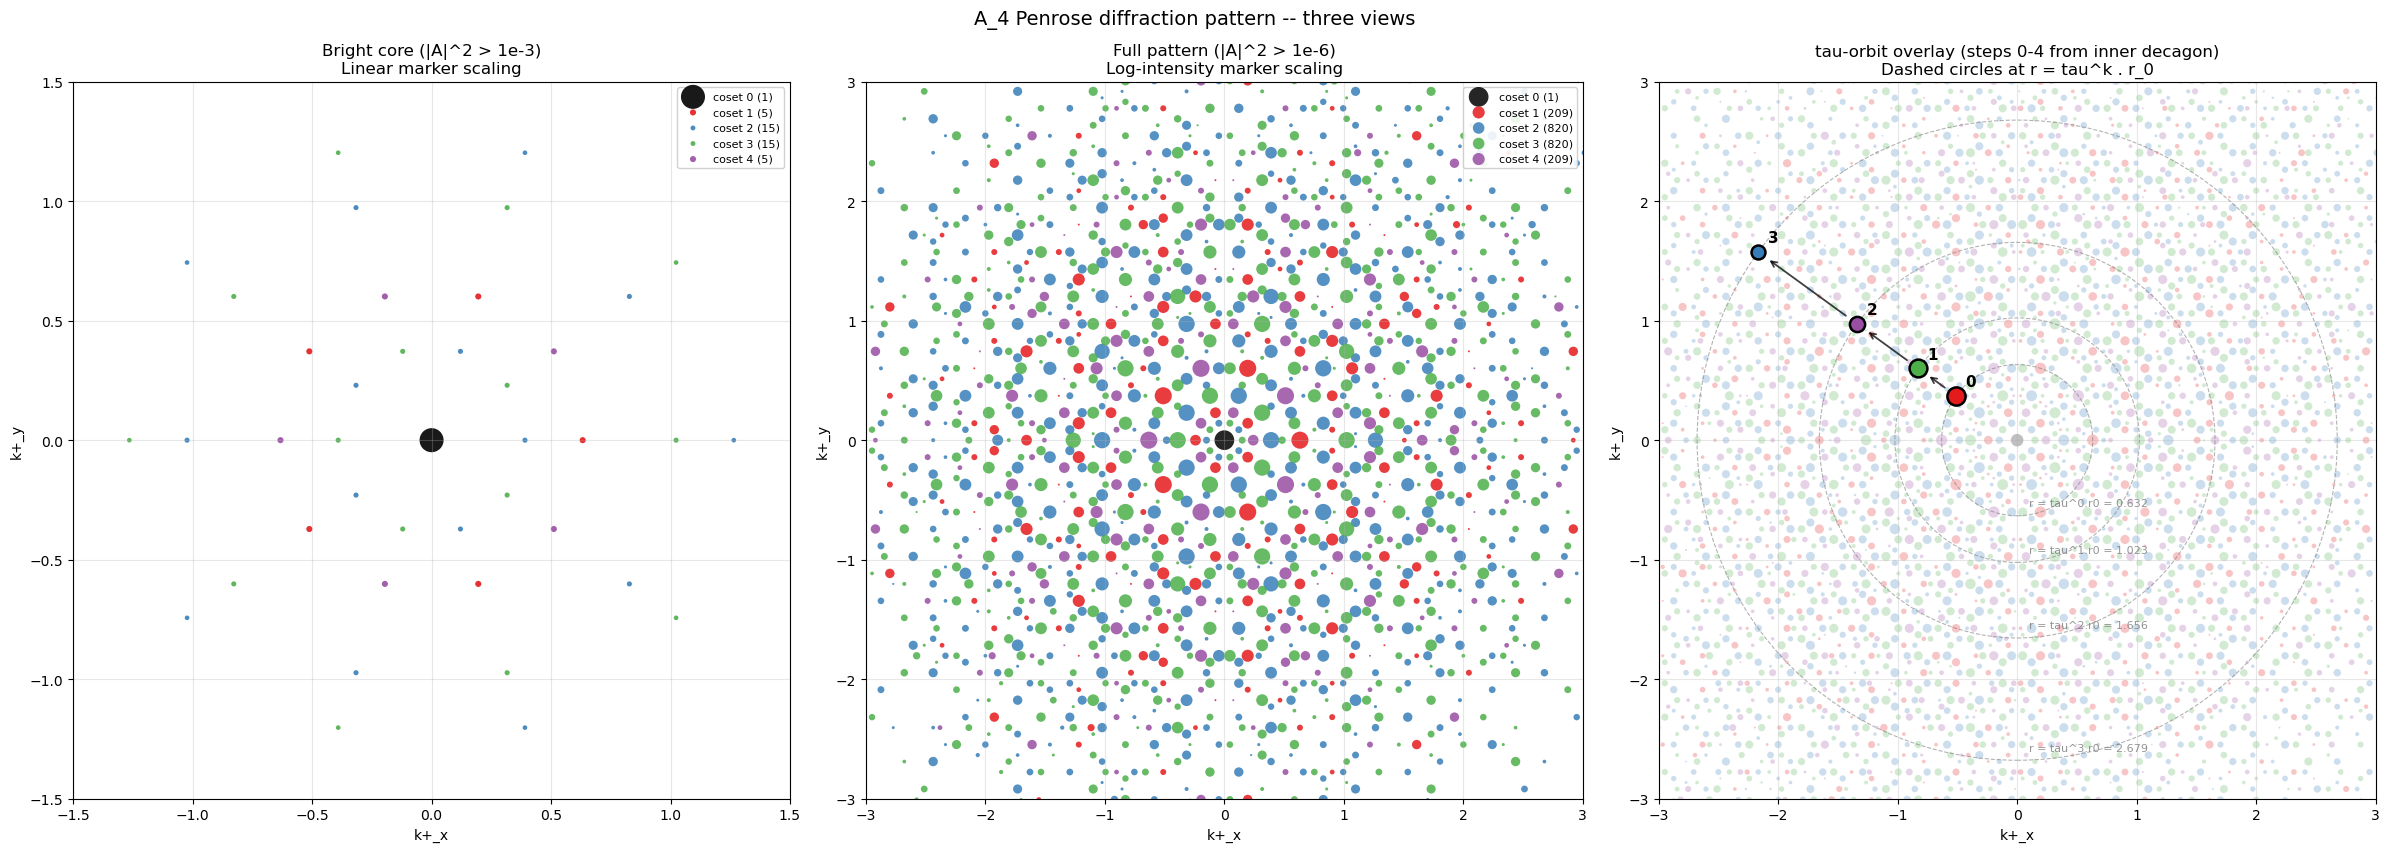

In [18]:
from matplotlib.patches import Circle

COSET_COLORS = {
    0: '#000000',   # origin (coset 0): black
    1: '#e41a1c',   # red
    2: '#377eb8',   # blue
    3: '#4daf4a',   # green
    4: '#984ea3',   # purple
}

fig, axes = plt.subplots(1, 3, figsize=(24, 8), facecolor='white')

Iall = np.array([p[2] for p in peaks_plot])
Imax = Iall.max()

# ---- Panel 1: Bright core (linear scaling, high threshold) ----
ax = axes[0]
I_min_1 = 1e-3
crop_1 = 1.5
for c in range(5):
    cpeaks = [p for p in peaks_plot if p[3] == c and p[2] >= I_min_1]
    if not cpeaks:
        continue
    xs = np.array([p[1][0] for p in cpeaks])
    ys = np.array([p[1][1] for p in cpeaks])
    Is = np.array([p[2] for p in cpeaks])
    sizes = 10 + 290 * Is / Imax
    ax.scatter(xs, ys, s=sizes, c=COSET_COLORS[c], alpha=0.90,
               edgecolors='none', label=f'coset {c} ({len(cpeaks)})')
ax.set_xlabel('k+_x'); ax.set_ylabel('k+_y')
ax.set_title(f'Bright core (|A|^2 > {I_min_1:.0e})\nLinear marker scaling')
ax.set_aspect('equal'); ax.set_xlim(-crop_1, crop_1); ax.set_ylim(-crop_1, crop_1)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9); ax.grid(True, alpha=0.3)

# ---- Panel 2: Full pattern (log-honest scaling, moderate threshold) ----
ax = axes[1]
I_min_2 = 1e-6
crop_2 = 3.0
peaks_panel2 = [p for p in peaks_unique if p[2] > I_min_2]
print(f'Panel 2: threshold {I_min_2:.0e} gives {len(peaks_panel2)} peaks')
for c in range(5):
    cpeaks = [p for p in peaks_panel2 if p[3] == c]
    if not cpeaks:
        continue
    xs = np.array([p[1][0] for p in cpeaks])
    ys = np.array([p[1][1] for p in cpeaks])
    Is = np.array([p[2] for p in cpeaks])
    sizes = 1.5 + 200 * (np.log10(Is) - np.log10(I_min_2)) / 6.0
    ax.scatter(xs, ys, s=sizes, c=COSET_COLORS[c], alpha=0.85,
               edgecolors='none', label=f'coset {c} ({len(cpeaks)})')
ax.set_xlabel('k+_x'); ax.set_ylabel('k+_y')
ax.set_title(f'Full pattern (|A|^2 > {I_min_2:.0e})\nLog-intensity marker scaling')
ax.set_aspect('equal'); ax.set_xlim(-crop_2, crop_2); ax.set_ylim(-crop_2, crop_2)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9); ax.grid(True, alpha=0.3)

# ---- Panel 3: tau-orbit overlay ----
ax = axes[2]
I_min_3 = 1e-8
peaks_panel3_bg = [p for p in peaks_unique if p[2] > I_min_3]

# Background: all peaks, faded
for c in range(5):
    cpeaks = [p for p in peaks_panel3_bg if p[3] == c]
    if not cpeaks:
        continue
    xs = np.array([p[1][0] for p in cpeaks])
    ys = np.array([p[1][1] for p in cpeaks])
    Is = np.array([p[2] for p in cpeaks])
    sizes = 1.5 + 80 * (np.log10(Is) - np.log10(I_min_3)) / 8.0
    ax.scatter(xs, ys, s=sizes, c=COSET_COLORS[c], alpha=0.25, edgecolors='none')

# Compute tau-orbit
n_orbit = n0.copy()
orbit_positions = []
orbit_intensities = []
orbit_cosets = []
r0 = np.linalg.norm(sum(n_orbit[k] * omega_plus[k] for k in range(4)))
for step in range(5):
    k_plus = sum(n_orbit[k] * omega_plus[k] for k in range(4))
    n_tup = tuple(int(ni) for ni in n_orbit)
    A2 = amplitude(n_tup)**2
    orbit_positions.append(k_plus)
    orbit_intensities.append(A2)
    orbit_cosets.append(coset_of(n_tup))
    n_orbit = M_tau_np @ n_orbit
orbit_positions = np.array(orbit_positions)

# Concentric dashed circles at tau-scaled radii (labels below x-axis)
for k in range(5):
    r = r0 * TAU**k
    if r > crop_2 * 1.2:
        break
    circle = Circle((0, 0), r, fill=False, linestyle='--',
                    edgecolor='gray', linewidth=0.8, alpha=0.6)
    ax.add_patch(circle)
    if abs(-r) < crop_2 * 0.95:
        ax.annotate(f'r = tau^{k}.r0 = {r:.3f}',
                    xy=(0, -r), xytext=(0.1, -r + 0.08),
                    fontsize=8, color='gray', alpha=0.85)

# Plot 5 orbit peaks with bold outlines and step labels
for i, (pos, I, c_i) in enumerate(zip(orbit_positions, orbit_intensities, orbit_cosets)):
    sz = 50 + 150 * (np.log10(max(I, I_min_3)) - np.log10(I_min_3)) / 8.0
    sz = max(40, min(sz, 280))
    ax.scatter([pos[0]], [pos[1]], s=sz, c=COSET_COLORS[c_i],
               edgecolors='black', linewidths=1.8, zorder=10)
    ax.annotate(f'{i}', xy=pos, xytext=(pos[0]+0.08, pos[1]+0.08),
                fontsize=11, fontweight='bold', zorder=11)

# Arrows between consecutive orbit peaks
for i in range(len(orbit_positions) - 1):
    start = orbit_positions[i]
    end = orbit_positions[i+1]
    if max(abs(end[0]), abs(end[1])) > crop_2:
        continue
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color='black', lw=1.3,
                                alpha=0.75, shrinkA=10, shrinkB=10),
                zorder=9)

ax.set_xlabel('k+_x'); ax.set_ylabel('k+_y')
ax.set_title(f'tau-orbit overlay (steps 0-4 from inner decagon)\n'
             f'Dashed circles at r = tau^k . r_0')
ax.set_aspect('equal'); ax.set_xlim(-crop_2, crop_2); ax.set_ylim(-crop_2, crop_2)
ax.grid(True, alpha=0.3)

plt.suptitle('A_4 Penrose diffraction pattern -- three views',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../penrose_diffraction_coxeter.png')
plt.show()


## 12.1 Reading the diffraction pattern

The three panels above each answer a different question about the pattern.
Here is what to see, and how each visual feature connects back to the
symbolic proofs in §§10–11.

### What to see in each panel

**Panel 1 — Bright core.** A central origin peak, surrounded by a ring of
10 bright peaks at radius r₀ ≈ 0.632 (the "inner decagon"), followed by a
second ring of 10 peaks at radius ≈ 1.02, with perhaps a third faint ring
at the outer edge. The inner decagon alternates between coset 1 (red) and
coset 4 (purple) every 36°. The second ring alternates between coset 2 (blue)
and coset 3 (green). The peak count in the legend reads
**1 + 5 + 15 + 15 + 5** — one origin, five peaks per coset in cosets 1 and 4
(the inner decagon split by coset), fifteen each in cosets 2 and 3 (the
second and third rings combined).

**Panel 2 — Full pattern.** A densely populated pattern with a clear
brightness gradient: large markers near the origin, progressively smaller
markers outward. The pattern appears rotationally symmetric under 72°, with
no distinguished Cartesian axes. Even at threshold 10⁻⁶, peaks fill the
visible region — about 2,000 peaks on display. The brightness decay
visible in this panel is the direct visual signature of the τ-scaling
self-similarity studied in §12: each τ-scaled ring is substantially dimmer
than the previous one.

**Panel 3 — τ-orbit overlay.** Five concentric dashed circles at radii
r₀ · τ⁰, r₀ · τ¹, r₀ · τ², r₀ · τ³, r₀ · τ⁴ (≈ 0.632, 1.023, 1.656, 2.679,
4.335). Four labeled peaks (0, 1, 2, 3) at successive τ-scaled radii, with
arrows showing the trajectory under iterated application of the integer
matrix M_τ^ω. The trajectory is **not radial**: consecutive points sit at
different angles, and their colors (cosets) change at each step, revealing
that M_τ is not merely a dilation but carries non-trivial angular content
via the Galois-conjugate action on cosets (c ↦ 3c mod 5). Step 4 falls
outside the displayed window.

### From observation to theorem

The visual features observed in the plots are exact mathematical facts.
Here is the correspondence:

| Visual observation | Becomes theorem in |
|---|---|
| Inner decagon has exactly 10 peaks, evenly spaced at 36° | §11: D₁₀ acts on peaks |
| All 10 inner-decagon peaks have the same intensity | §11: Coxeter + inversion preserves amplitudes |
| Rings occur at radii in geometric progression with ratio τ | §12: M_τ² = M_τ + I exactly |
| Coset colors alternate 1↔4 around the inner decagon | §11: inversion sends c ↦ −c mod 5 |
| τ-orbit walks through cosets 1→3→4→2→1 | §12: M_τ acts on cosets by c ↦ 3c mod 5 |
| Intensity decreases with each τ-scaling step | §12: sinc-product decay along M_τ-orbit |
| Only the origin is colored black (coset 0) | §8: sinc-product extinction rule on Q(A₄) |

Each entry in the right column is a specific algebraic identity verified in
exact arithmetic — typically as an integer-matrix identity in GL₄(ℤ),
occasionally as an identity in the cyclotomic field ℚ(ζ₅). The passage from
picture to theorem is the central move of this notebook: the observed
symmetries are not approximate or statistical but exact consequences of the
representation theory of the A₄ root system.

### A subtle point about density

A reader accustomed to crystallographic diffraction may be struck by how
*full* Panel 2 is. A conventional 2D crystal has diffraction peaks on a
discrete 2D lattice — a sparse, regular grid. Panel 2 shows something
qualitatively different: peaks fill the plane densely, at every scale.

This is not an artifact of the plot threshold or the finite enumeration.
The set π∥(P(A₄)) is a **rank-4 ℤ-module densely embedded in the 2D plane
E∥** — integer combinations of four 2-vectors that are linearly independent
over ℤ but not over ℝ. Between any two peak positions there is always
another peak position. Yet the set of peaks remains countable and measure
zero in the plane; most peaks have vanishingly small intensity. This dense-
but-countable structure is one of the defining features distinguishing
quasicrystals from both periodic crystals (where peaks form a discrete
lattice) and amorphous materials (where there are no sharp peaks at all).

The cut-and-project origin of this density is clear: P(A₄) is a genuine
rank-4 lattice in 4-dimensional space, projected into 2-dimensional E∥.
A lattice of rank higher than the ambient dimension necessarily projects
to a dense subset. The diffraction pattern is, in effect, the 2D shadow
of a 4D reciprocal lattice.


## Development notes and next steps

This section documents design decisions made during the notebook's
development, corrections applied during verification, and open directions
for further work. Its purpose is to provide context for future refinements
— including refinements done by a fresh session continuing from this
notebook alone.

### Design choices and alternatives considered

**Weight lattice P(A₄) vs. ℤ⁵/(1,1,1,1,1) as the dual lattice.** The
notebook uses P(A₄), which is rank 4 natively and mathematically canonical
(the literal dual of Q(A₄)). The alternative ℤ⁵/(1,1,1,1,1) is equivalent
after projection to E∥ or E⊥ — both kill the E₀ direction along (1,1,1,1,1)
— but requires quotienting out a 5-element redundancy. §6 includes a brief
remark on the equivalence. The P(A₄) choice matches the mathematical
register of the notebook better; either could be used with identical
numerical results.

**Hyperplane lift of fundamental weights.** Sage's default
`ambient.fundamental_weights()` returns ωₖ = ε₁ + … + εₖ (integer entries,
not in the A₄ hyperplane). The sinc-product amplitude formula requires the
hyperplane lift ωₖ = Σᵢ≤ₖ εᵢ − (k/5) Σᵢ εᵢ (entries in (1/5)ℤ), because
the (1/5)ℤ fractions are what encode the Penrose four-layer structure.
We project explicitly in §4.

**Enumeration cutoff N = 6.** Chosen empirically after observing that
N = 4 gave a visible Cartesian artifact at the periphery of the diffraction
plot (preferential enumeration of lattice directions near the corners of
the ℤ⁴ box). N = 6 produces ~28,000 candidate peaks with acceptable
run-time and a visually isotropic pattern. For higher-resolution plots or
more aggressive symbolic checks, N = 8 or above would be reasonable.

**Intensity thresholds.** The three-panel plot uses three different
thresholds: 10⁻³ (bright core, linear marker scaling), 10⁻⁶ (full pattern,
log marker scaling), 10⁻⁸ (τ-orbit background context). These were chosen
to make distinct pedagogical points: the bright core shows the D₁₀ structure
cleanly, the full pattern shows intensity decay honestly, the τ-orbit
context includes enough background peaks that the overlay is embedded in
the pattern rather than floating on white space.

**Number of τ-orbit iterations displayed (5).** The orbit starts at an
inner-decagon peak (radius √(2/5) ≈ 0.632) and iterates M_τ^ω five times,
producing peaks at radii 0.632, 1.023, 1.656, 2.679, 4.335. The fifth step
falls outside the plot crop of ±3; four are visible. Extending to more
steps is trivial; the question is whether the additional data adds
pedagogical value or merely clutter.

### Corrections applied during verification

**Coxeter element preserves cosets, does not shift them.** An earlier draft
claimed the Coxeter element acts on P(A₄)/Q(A₄) ≅ ℤ/5ℤ by the shift
c ↦ c + 1 mod 5. This was incorrect: the Weyl group acts trivially on the
weight-modulo-root quotient (a general fact, since Weyl groups preserve
the root lattice). The correct statement, verified in §11, is that P
preserves each coset setwise. The observed 10-fold dihedral pattern comes
from combining the 5-fold Coxeter rotation with the independent inversion
symmetry c ↦ −c mod 5, not from a cyclic coset shift.

**Self-similarity is positional, not full-measure.** An earlier draft
suggested amplitudes would stay "roughly constant" along the τ-orbit
because of the E⊥ contraction. In fact, amplitudes decay rapidly along
the orbit (by 4–8 orders of magnitude across 5 iterations), because the
E∥ and E₀ contributions to the ε-coordinates grow faster than the E⊥
contribution shrinks. The correct statement is that the *support* of the
diffraction measure is τ-invariant; the measure itself is not. This is
now discussed explicitly in §12.

**Plot intensity scaling.** The first version of the §10 plot used a
power-law compression `(I/Imax)^0.4` that visually flattened the
intensity distribution, masking the rapid decay that §12 reveals. The
current version uses linear scaling for the bright-core panel and
log-honest scaling for the full-pattern panel, making the intensity decay
visible without explicit explanation.

**Sinc-product formula automatic layer sum.** An early sketch proposed
summing the window Fourier transform separately over the four Penrose
layers. This was unnecessary: the 5D hypercube Fourier transform,
evaluated at a weight-lattice point whose ε-coordinates are fifths of
integers, automatically handles the layer structure through the fractional
parts. §7 states this cleanly; no layer-by-layer summation appears in
the code.

### Open questions and extensions

The following directions are natural extensions of this notebook's
framework, not pursued here:

**Direct comparison with a finite tiling.** The notebook computes the
analytic diffraction pattern of the infinite Penrose model set. A
complementary calculation would compute the structure factor
S(k) = |Σ exp(−2πi k·v)|² of a finite vertex set (generated by the
companion tiling notebook) and verify its convergence to the analytic
formula as the patch grows. This would quantify finite-size effects
(peak broadening, sidelobes) and provide an empirical bridge between
the two notebooks.

**Icosahedral quasicrystals (3D).** Replacing A₄ with H₃ or the projection
from E₈ to H₄ extends the framework to 3D icosahedral quasicrystals (the
type Shechtman originally observed in Al-Mn alloys). The Coxeter structure
is more elaborate — H₃ and H₄ are non-crystallographic, so they must be
derived from D₆ or E₈ respectively — but the overall narrative (eigenspace
decomposition → weight lattice → sinc-product amplitudes → integer-matrix
symmetries) carries over.

**Phason modes.** Allowing q₀ to vary continuously (not just as a fixed
rational shift) introduces phason degrees of freedom: continuous
deformations of the tiling that leave the diffraction peaks in place but
modulate their amplitudes. A phason-dynamics extension of this notebook
would visualize peak intensities as q₀ is varied, and verify the structure
factor's invariance of positions under phason modes.

**Other quasicrystal families.** The Ammann-Beenker (8-fold), 12-fold,
and generalized n-fold tilings have analogous Coxeter descriptions. The
same framework, with appropriate substitution of the root system, would
produce their diffraction patterns.

**Physical calibration.** The notebook uses A(0) = 1 as its normalization
convention, producing dimensionless intensity ratios. For comparison with
experimental diffraction (X-ray, electron, neutron), one would need to
include atomic form factors, Debye-Waller factors, and a physical
normalization tied to the scatterer density.

### References cited in the notebook

- A. Hof, *On diffraction by aperiodic structures*, Commun. Math. Phys.
  169 (1995), 25–43.
- M. Schlottmann, *Generalized model sets and dynamical systems*, in
  *Directions in Mathematical Quasicrystals*, AMS (2000).
- L. Boyle and P. Steinhardt, *Coxeter Pairs, Ammann Patterns, and
  Penrose-like Tilings*, arXiv:1608.08215.
- M. Baake and U. Grimm, *Aperiodic Order, Vol. 1: A Mathematical
  Invitation*, Cambridge University Press (2013).
